In [1]:
import distribution_of_relaxation_times as drt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Define plotting assistants 
# List of default colors
color = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Plot parameters and sizes
plt.rc('font', size = 16)
plt.rc('axes', linewidth=1, titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)    # fontsize of the x and y labels
plt.rc('xtick', top=True, bottom=True, direction='in')
plt.rc('ytick', left=True, right=True, direction='in') 
plt.rc('figure', titlesize=5)
plt.rc('legend', fontsize=14)
plt.rc('lines', linewidth=2)

In [3]:
# Read in the simulation data
data = pd.read_csv("Simulation Results/tj.dat", sep=r'\s+')

[]

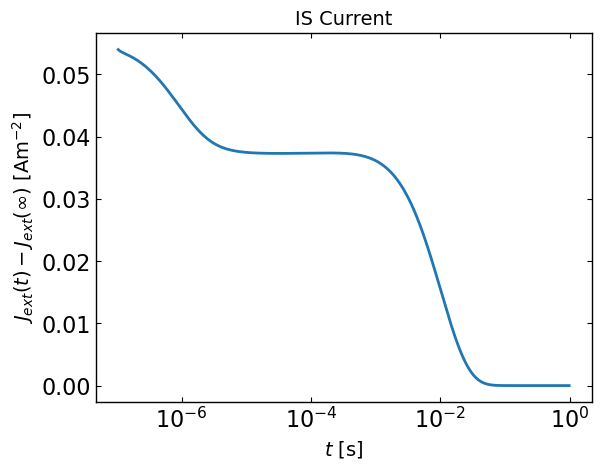

In [4]:
# Reduce the window of current and time to be used for fitting
start_index = 57
end_index = 849

time = data['t'].iloc[start_index:end_index].values
current_density = (data['Jext'].iloc[start_index:end_index].values - data['Jext'].iloc[-1])

plt.plot(time, current_density)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)-J_{ext}(\\infty)$ [$\\text{A} \\text{m}^{-2}$]')
plt.title("IS Current")
plt.plot()

In [5]:
# Fit a Z_DRT curve to the solution for 2 events
# Set initial guess of solution
U0 = [0, 0]
tau0 = np.geomspace(time[0], time[-1], 2)

fit1 = drt.fit_Z_DRT(time, current_density, U0, tau0)

In [6]:
# Try running the fit again using the old fit values as the new params
fit2 = drt.fit_Z_DRT(time, current_density, fit1.U, fit1.tau)

[]

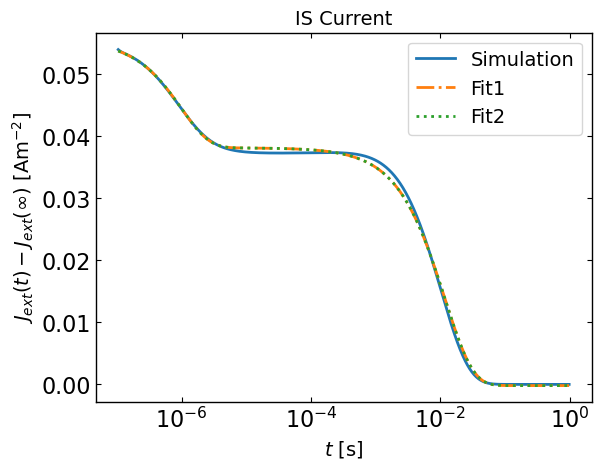

In [7]:
# Plot the fit against the current window to compare results
current_DRT1 = drt.Z_DRT(time, fit1.U, fit1.tau, fit1.offset)
current_DRT2 = drt.Z_DRT(time, fit2.U, fit2.tau, fit2.offset)

plt.plot(time, current_density, label='Simulation')
plt.plot(time, current_DRT1, label='Fit1', linestyle='-.')
plt.plot(time, current_DRT2, label='Fit2', linestyle=':')

plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)-J_{ext}(\\infty)$ [$\\text{A} \\text{m}^{-2}$]')
plt.title("IS Current")
plt.legend()
plt.plot()

In [9]:
# Now we can try using the multi-fit function to find the optimal number of exponentials to use
fits = drt.multi_fit_Z_DRT(time, current_density, range(1,10))

[]

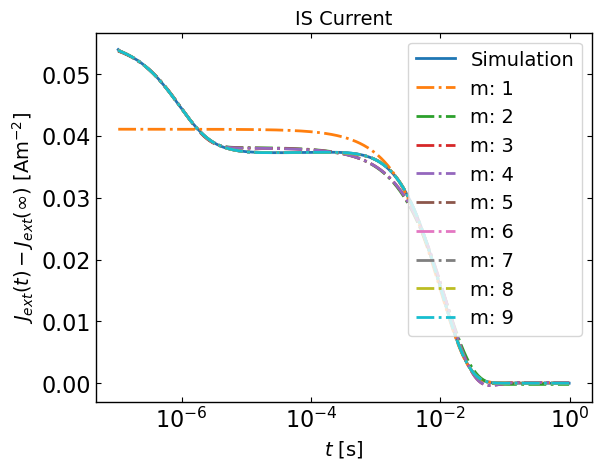

In [25]:
# Plot all the fits 
plt.plot(time, current_density, label='Simulation')
for fit in fits:
    current_DRT = drt.Z_DRT(time, fit.U, fit.tau, fit.offset)
    plt.plot(time, current_DRT, label=f'm: {fit.m}', linestyle='-.')

plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)-J_{ext}(\\infty)$ [$\\text{A} \\text{m}^{-2}$]')
plt.title("IS Current")
plt.legend()
plt.plot()

Text(0.5, 1.0, 'Cost Across Broadening Distributions of Relaxation Times')

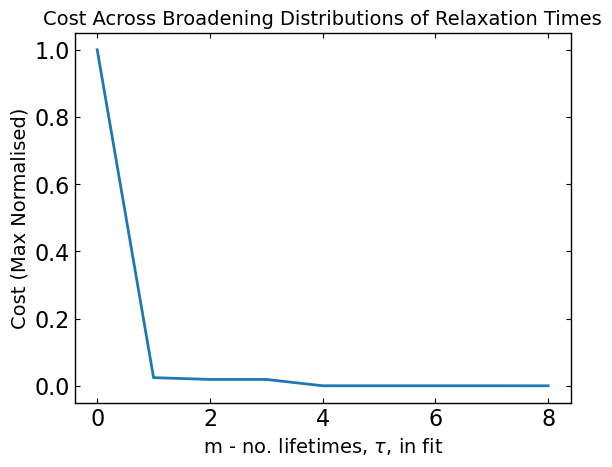

In [32]:
costs = [fit.cost for fit in fits]

plt.plot(range(len(costs)), costs/max(costs))
plt.xlabel("m - no. lifetimes, $\\tau$, in fit")
plt.ylabel("Cost (Max Normalised)")
plt.title("Cost Across Broadening Distributions of Relaxation Times")